In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
preflop_path = Path.cwd().parent / 'training' / 'preflops'  
rng_seed = 42

def get_preflop_path(iter):
    return preflop_path / ("potbet_prob_" + str(iter) + ".csv")

In [3]:
import numpy as np
import matplotlib.pyplot as plt

RANKS = "AKQJT98765432"


def hand_name(i: int, j: int) -> str:
    """Standard grid convention: diag=pair, upper-right=suited, lower-left=offsuit."""
    hi, lo = RANKS[min(i, j)], RANKS[max(i, j)]
    if i == j:
        return hi + hi
    return hi + lo + ("s" if i < j else "o")


def plot_preflop_grid(df, prob_col="prob", ax=None, title=None):
    """13x13 preflop grid from a df with columns [hand, prob_col], colored red->green."""
    probs = dict(zip(df["hand"], df[prob_col]))
    grid = np.array([[probs.get(hand_name(i, j), np.nan) for j in range(13)]
                     for i in range(13)])

    if ax is None:
        _, ax = plt.subplots(figsize=(9, 9))

    ax.imshow(grid, cmap="RdYlGn", vmin=0, vmax=1)

    for i in range(13):
        for j in range(13):
            v = grid[i, j]
            label = hand_name(i, j) if np.isnan(v) else f"{hand_name(i, j)}\n{v:.0%}"
            ax.text(j, i, label, ha="center", va="center", fontsize=7)

    # white gridlines between cells, no outer frame or tick marks
    ax.set_xticks(np.arange(-0.5, 13), minor=True)
    ax.set_yticks(np.arange(-0.5, 13), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks(range(13), RANKS)
    ax.set_yticks(range(13), RANKS)
    ax.set_title(title or prob_col, fontsize=12, pad=10)
    return ax

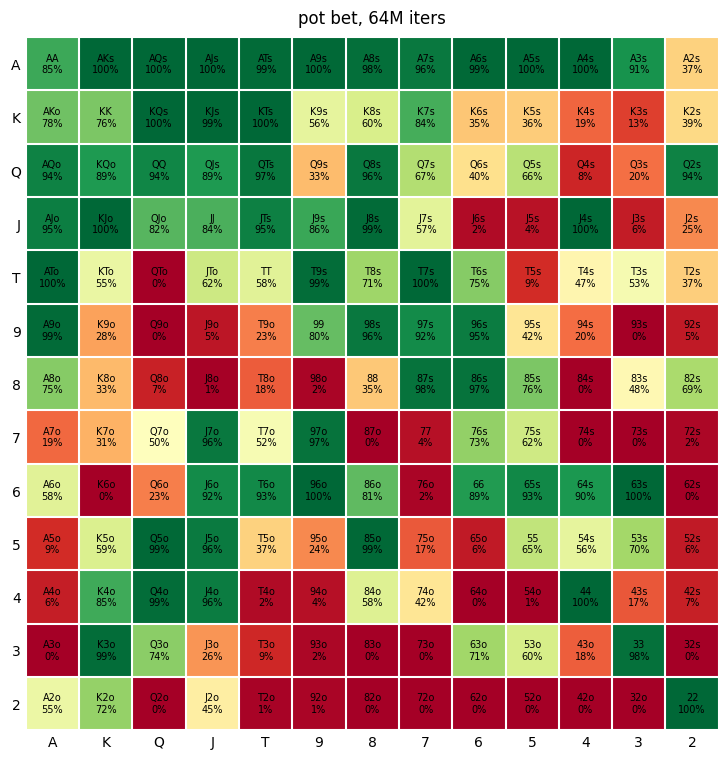

In [5]:
df = pd.read_csv(get_preflop_path(64_000_000))
plot_preflop_grid(df, title="pot bet, 64M iters")
plt.show()